# geovalidate — usage examples

The `geovalidate` package is intended for performant spatial cross-validation, resampling/permutation inference methods, and spatial model criticism. This example shows how to use four point sampling strategies using the **NYC boroughs** (nybb) dataset from [geodatasets](https://geodatasets.readthedocs.io). 

Point sampling is a common task for validating space-filling *field prediction models*, which can generate unique predictions at any point in a study area. We often need to design structured cross-validation exercises on data in order to assess these models. Unfortunately, it's not always the best to sample randomly from a study area. Sometimes, we need to make sure that we sample evenly within given observation types, or sample evaluation points proportional to some weighted score/value. 

The samplers in `geovalidate` work by re-sampling points in a random/structured manner from the study area. Four samplers are currently implemented:

| Class | What it does |
|---|---|
| `PointSampler` | Uniform random points inside any Shapely geometry |
| `ConstantClassSampler` | Exactly *n* points from every class |
| `StratifiedClassSampler` | Fixed total allocated proportionally to a value column |
| `MultinomialSampler` | Multinomial allocation across label groups weighted by a per-geometry value |

Each sampler also accepts `quasi_random="sobol"`, `"halton"`, or `"r2"` to replace the default uniform RNG with a low-discrepancy sequence. Quasi-random sequences have better space-filling properties than points sampled at random, meaning that they tend to be less "clumpy" than randomly-sampled points. These options are only supported for some samplers.

In [1]:
import geodatasets
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.io import MemoryFile
from rasterio.transform import from_bounds
import colormaps

from geovalidate import (
    ConstantClassSampler,
    MultinomialSampler,
    PointSampler,
    StratifiedClassSampler,
)

%matplotlib inline

In [2]:
nybb = gpd.read_file(geodatasets.get_path("nybb"))
print(nybb.crs)
nybb[["BoroName", "Shape_Leng", "Shape_Area"]]

EPSG:2263


,BoroName,Shape_Leng,Shape_Area
0,Staten Island,330470.010332,1.623820e+09
1,Queens,896344.047763,3.045213e+09
2,Brooklyn,741080.523166,1.937479e+09
3,Manhattan,359299.096471,6.364715e+08
4,Bronx,464392.991824,1.186925e+09


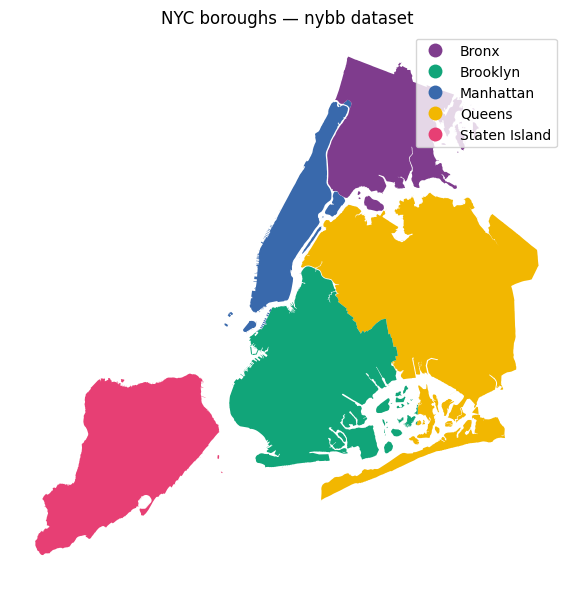

In [3]:
BORO_COLORS = dict(zip(nybb.BoroName, colormaps.bold[:5].colors))
ax = nybb.plot(
    column="BoroName", 
    categorical=True, 
    cmap=colormaps.bold[:5], 
    legend=True, figsize=(6, 6)
)
ax.set_title("NYC boroughs — nybb dataset")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 1 · Single geometry — `PointSampler`

`PointSampler` draws uniform random points inside any Shapely geometry using batch rejection sampling with Shapely 2 vectorised `contains` checks. This improves upon the past implementation in `pointpats`, which samples single points at a time. We'll sample directly from Brooklyn as an example. 

In [4]:
geom = nybb.loc[nybb.BoroName == "Brooklyn", "geometry"].iloc[0]
print(f"Geometry type : {geom.geom_type}")
print(f"Sub-polygons  : {len(geom.geoms)}")

pts = PointSampler(n_samples=600, random_state=42).sample(geom)
print(f"Sampled {len(pts)} points")
pts.head(3)

Geometry type : MultiPolygon
Sub-polygons  : 27
Sampled 600 points


,geometry
0,POINT (994280.771 167818.669)
1,POINT (1014953.665 172083.85)
2,POINT (1007242.376 166002.806)


Now, `pts` is a set of randomly-sampled points from within the Brooklyn borough boundary. 

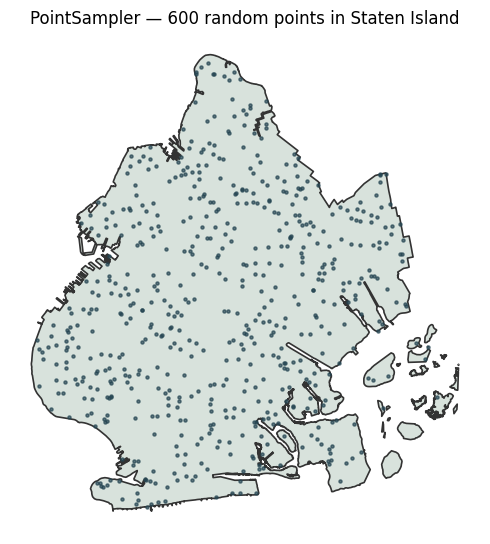

In [5]:
fig, ax = plt.subplots(figsize=(5, 6))
gpd.GeoSeries([geom]).plot(ax=ax, color="#d8e2dc", edgecolor="#333", linewidth=1.2)
ax.scatter(pts.geometry.x, pts.geometry.y, s=5, c="#264653", alpha=0.7, zorder=3)
ax.set_title("PointSampler — 600 random points in Staten Island")
ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

Note how the points are a bit clumpy---they tend to cluster together visually in a few places. We can smooth this out using the quasi-random sequences for sampling points. The `quasi_random=` keyword argument replaces the uniform RNG with a quasi-random sequence that is more effective for space-filling sampling; `sobol`, `halton`, and `r2` sequences are supported. 

The comparison below samples **300 points** from Staten Island three ways. Quasi-random sequences fill the space more evenly — notice fewer clusters and gaps compared to the random draw.

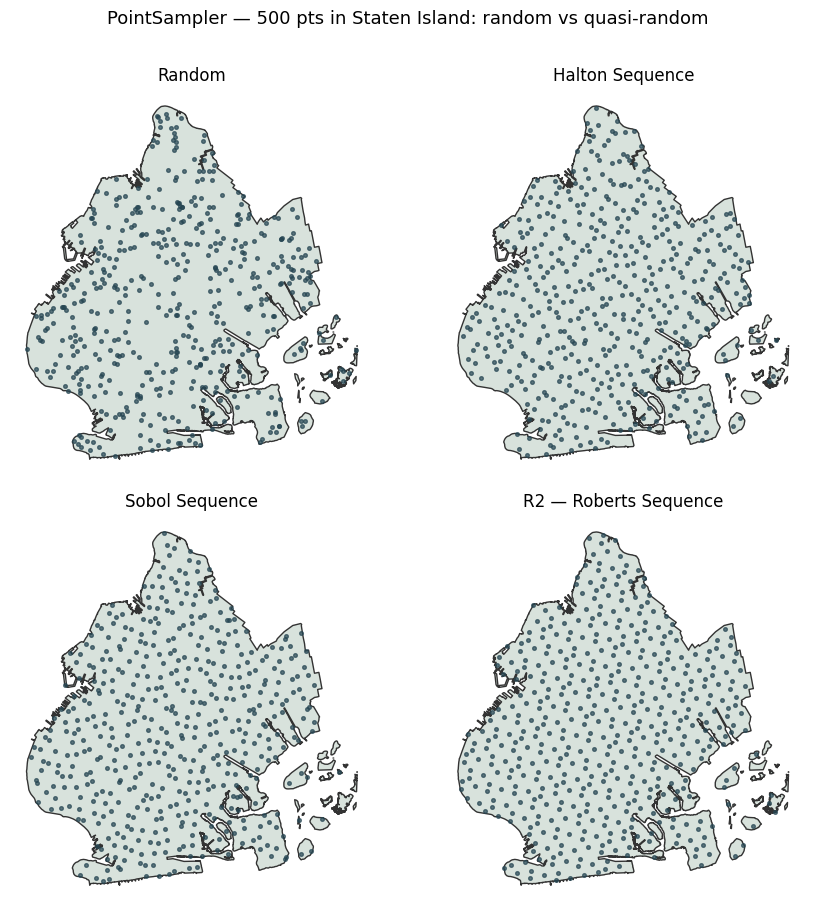

In [6]:
configs = [
    (None,     "Random"),
    ("halton", "Halton Sequence"),
    ("sobol", "Sobol Sequence"),
    ("r2",     "R2 — Roberts Sequence"),
]

fig, axes = plt.subplots(2, 2, figsize=(9,9))
for ax, (seq, title) in zip(axes.flat, configs):
    gpd.GeoSeries([geom]).plot(ax=ax, color="#d8e2dc", edgecolor="#333", linewidth=1)
    p = PointSampler(500, quasi_random=seq, random_state=85711).sample(geom)
    ax.scatter(p.geometry.x, p.geometry.y, s=7, c="#264653", alpha=0.7, zorder=3)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")

plt.suptitle("PointSampler — 500 pts in Staten Island: random vs quasi-random",
             fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## 2 · GeoDataFrame — class-aware samplers

We use the five boroughs as classes, with `Shape_Area` (sq ft) as the value column.  The contrast between `ConstantClassSampler` and
`StratifiedClassSampler` is most visible because borough areas differ by nearly 5x.

In [7]:
nybb[["BoroName", "Shape_Area"]].assign(
    area_km2=(nybb.Shape_Area * 0.0929 / 1e6).round(1)   # sq-ft → km²
).sort_values("area_km2", ascending=False)

,BoroName,Shape_Area,area_km2
1,Queens,3.045213e+09,282.9
2,Brooklyn,1.937479e+09,180.0
0,Staten Island,1.623820e+09,150.9
4,Bronx,1.186925e+09,110.3
3,Manhattan,6.364715e+08,59.1


In [8]:
# ConstantClassSampler: exactly 80 pts from every borough
pts_const = ConstantClassSampler(n_per_class=80, random_state=0).sample(
    nybb.geometry, nybb["BoroName"]
)

# StratifiedClassSampler: 400 total, allocated ∝ Shape_Area
pts_strat = StratifiedClassSampler(n_samples=400, random_state=0).sample(
    nybb.geometry, nybb["BoroName"], nybb["Shape_Area"]
)

print("ConstantClassSampler — points per borough:")
print(pts_const.groupby("class_label").size().rename("n").to_string())
print()
print("StratifiedClassSampler — points per borough (∝ area):")
print(pts_strat.groupby("class_label").size().rename("n").to_string())

ConstantClassSampler — points per borough:
class_label
Bronx            80
Brooklyn         80
Manhattan        80
Queens           80
Staten Island    80

StratifiedClassSampler — points per borough (∝ area):
class_label
Bronx             56
Brooklyn          92
Manhattan         30
Queens           145
Staten Island     77


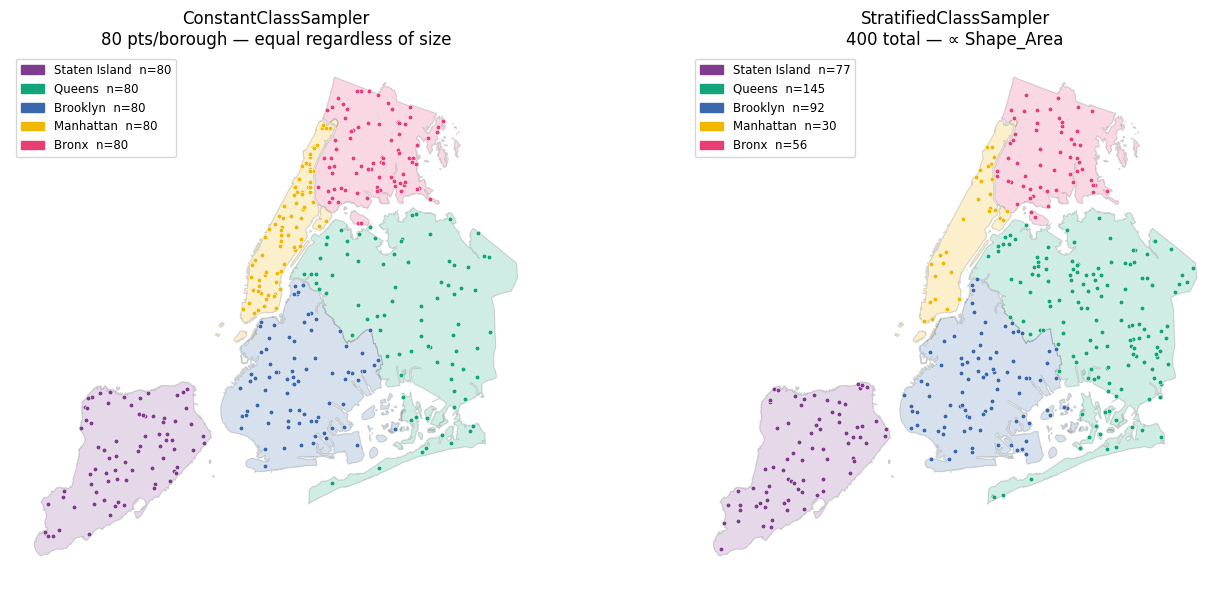

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pts, title in [
    (axes[0], pts_const, "ConstantClassSampler\n80 pts/borough — equal regardless of size"),
    (axes[1], pts_strat, "StratifiedClassSampler\n400 total — ∝ Shape_Area"),
]:
    for _, row in nybb.iterrows():
        gpd.GeoSeries([row.geometry]).plot(
            ax=ax, color=BORO_COLORS[row.BoroName], alpha=0.2,
            edgecolor="#444", linewidth=0.8)
    for name, color in BORO_COLORS.items():
        sub = pts[pts["class_label"] == name]
        if len(sub):
            ax.scatter(sub.geometry.x, sub.geometry.y, s=12, color=color, zorder=3,
                       edgecolors="white", linewidths=0.4)
    counts = pts.groupby("class_label").size()
    patches = [
        mpatches.Patch(
            color=BORO_COLORS[k], 
            label=f"{k}  n={counts.get(k, 0)}"
        )
        for k in BORO_COLORS
    ]
    ax.legend(handles=patches, fontsize=8.5)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")

fig.tight_layout()
plt.show()

This also works with pseudo-random sequences

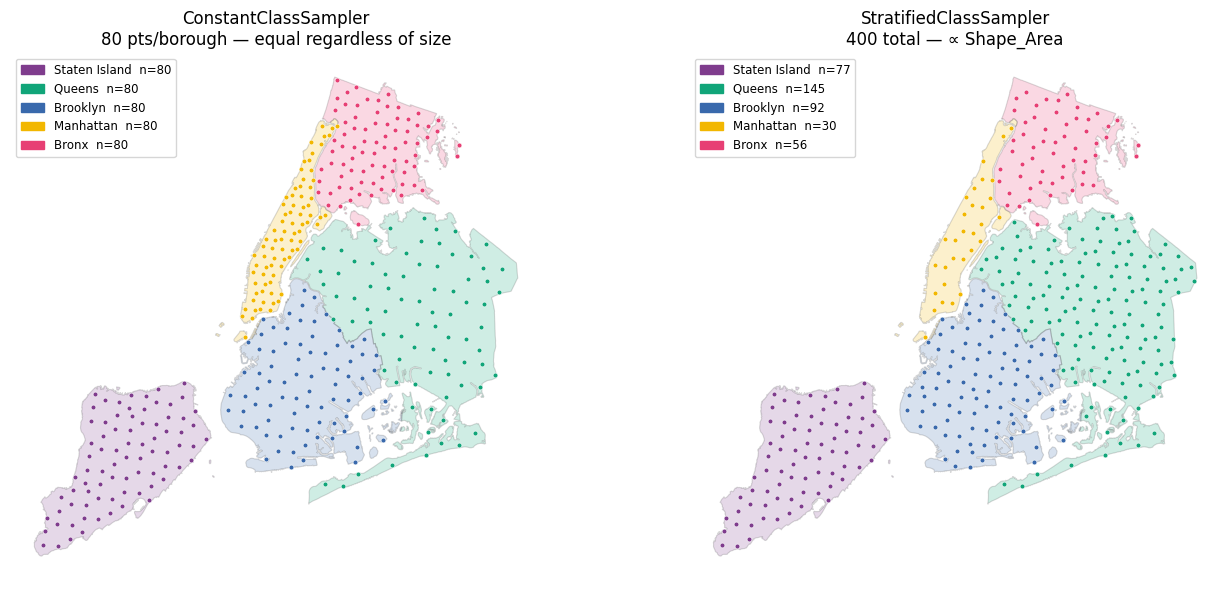

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pts_const = ConstantClassSampler(n_per_class=80, random_state=85711, quasi_random="r2").sample(
    nybb.geometry, nybb["BoroName"]
)
pts_strat = StratifiedClassSampler(n_samples=400, random_state=85711, quasi_random="r2").sample(
    nybb.geometry, nybb["BoroName"], nybb["Shape_Area"]
)

for ax, pts, title in [
    (axes[0], pts_const, "ConstantClassSampler\n80 pts/borough — equal regardless of size"),
    (axes[1], pts_strat, "StratifiedClassSampler\n400 total — ∝ Shape_Area"),
]:
    for _, row in nybb.iterrows():
        gpd.GeoSeries([row.geometry]).plot(
            ax=ax, color=BORO_COLORS[row.BoroName], alpha=0.2,
            edgecolor="#444", linewidth=0.8)
    for name, color in BORO_COLORS.items():
        sub = pts[pts["class_label"] == name]
        if len(sub):
            ax.scatter(
                sub.geometry.x,
                sub.geometry.y,
                s=12,
                color=color,
                zorder=3,
                edgecolors="white",
                linewidths=0.4
            )
    counts = pts.groupby("class_label").size()
    patches = [
        mpatches.Patch(
            color=BORO_COLORS[k],
            label=f"{k}  n={counts.get(k, 0)}"
        )
        for k in BORO_COLORS
    ]
    ax.legend(handles=patches, fontsize=8.5)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")

fig.tight_layout()
plt.show()

### `MultinomialSampler` on a GeoDataFrame

The `MultinomialSampler` works in two stages:

1. Sum *weights* within each *labels* group to get a per-class total weight $W_k$. Draw class sample counts jointly from $(n_1, n_2, \dots, n_k) \sim \text{Multinomial}(N, W_k / \sum W_k)$ — counts always sum to exactly `n_samples` but vary stochastically across runs.
2. Sample $n_k$ points uniformly from within the union of class $k$'s geometries.

This contrasts with `StratifiedClassSampler`, which allocates class counts *deterministically* using the largest-remainder (Hamilton) method. Here we'll use `Shape_Area` as the per-borough weight, so larger boroughs attract proportionally more sample points — but with random variation. This is most noticable if you'd like to make sure that your subclass sampling counts to vary realistically from run to run, rather than being constrained to be proportional to the weight. 

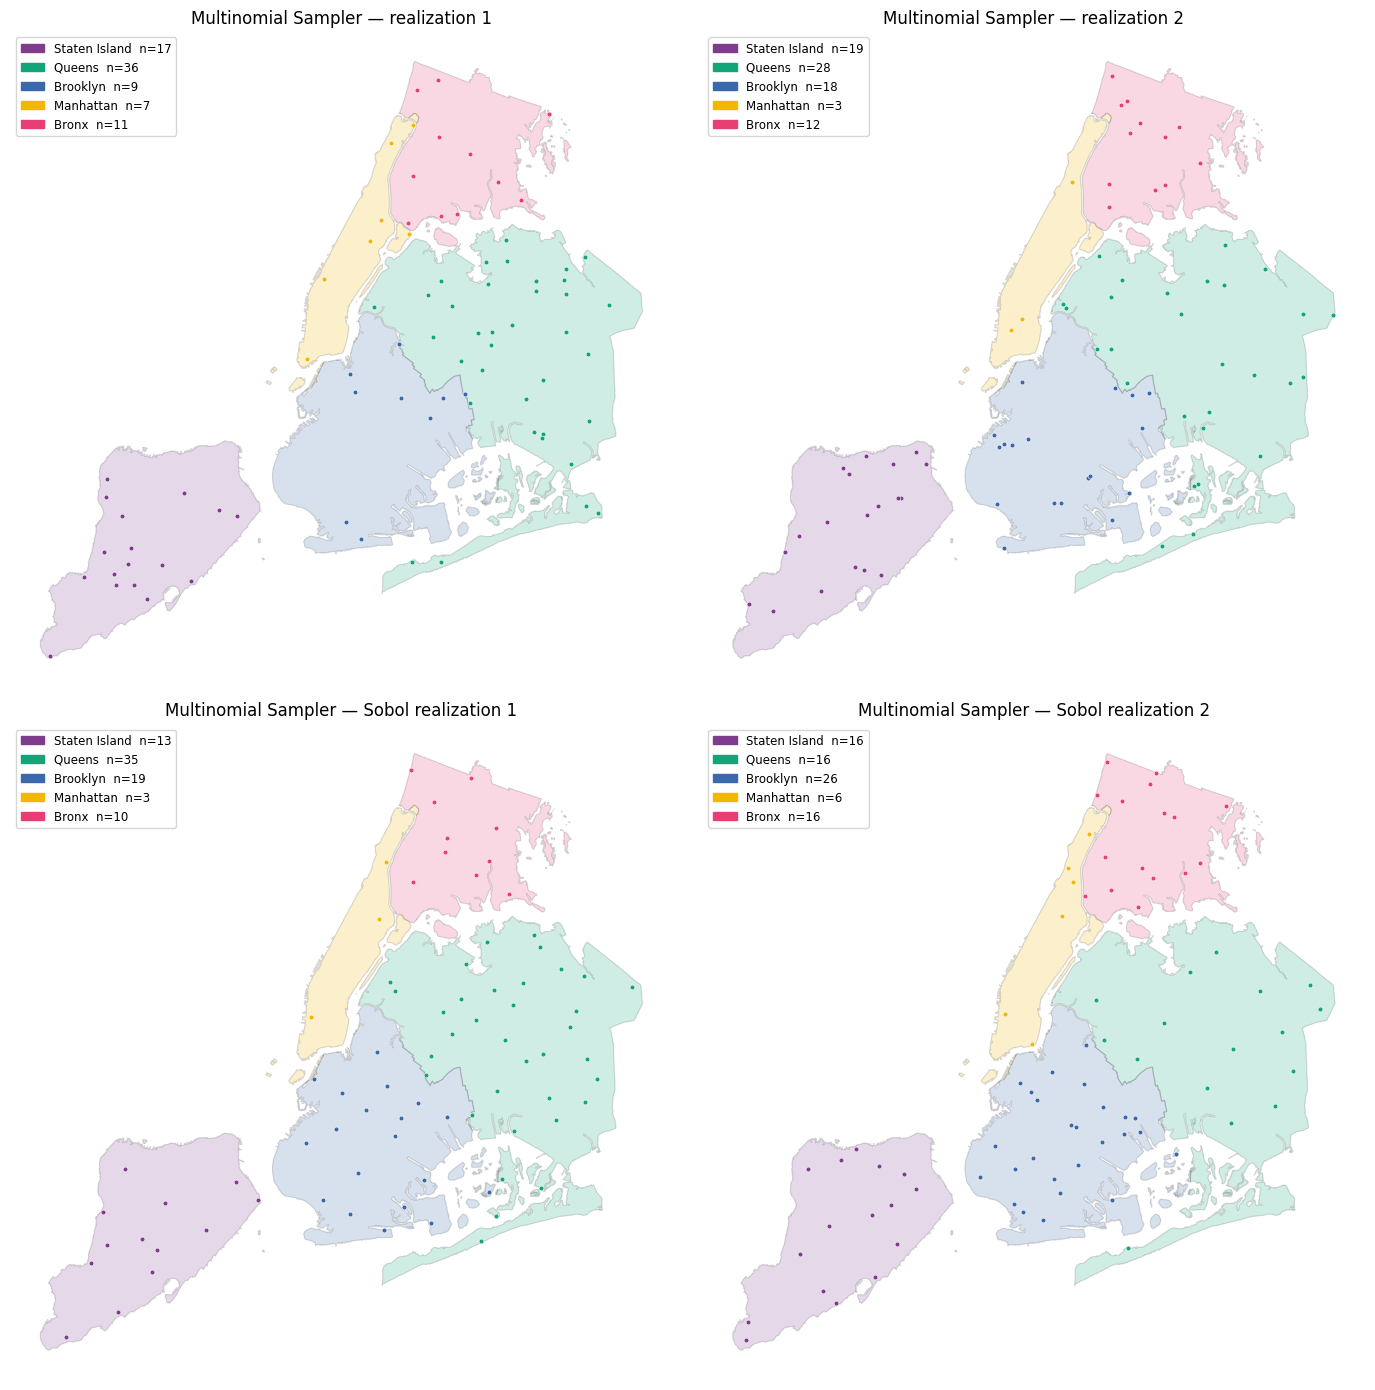

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

mp1 = MultinomialSampler(
    n_samples=80, 
    random_state=85711
).sample(nybb.geometry, labels=nybb.BoroName, weights=nybb.geometry.area)
mp2 = MultinomialSampler(
    n_samples=80, 
    random_state=85735
).sample(nybb.geometry, labels=nybb.BoroName, weights=nybb.geometry.area)
mq1 = MultinomialSampler(
    n_samples=80, 
    quasi_random='sobol', 
    random_state=85281
).sample(nybb.geometry, labels=nybb.BoroName, weights=nybb.geometry.area)
mq2 = MultinomialSampler(
    n_samples=80, 
    quasi_random='sobol', 
    random_state=11222
).sample(nybb.geometry, labels=nybb.BoroName, weights=nybb.geometry.area)

for ax, pts, title in [
    (axes.flat[0], mp1, "Multinomial Sampler — realization 1"),
    (axes.flat[1], mp2, "Multinomial Sampler — realization 2"),
    (axes.flat[2], mq1, "Multinomial Sampler — Sobol realization 1"),
    (axes.flat[3], mq2, "Multinomial Sampler — Sobol realization 2")
]:
    for _, row in nybb.iterrows():
        gpd.GeoSeries([row.geometry]).plot(
            ax=ax, color=BORO_COLORS[row.BoroName], alpha=0.2,
            edgecolor="#444", linewidth=0.8)
    for name, color in BORO_COLORS.items():
        sub = pts[pts["class_label"] == name]
        if len(sub):
            ax.scatter(sub.geometry.x, sub.geometry.y, s=12, color=color, zorder=3,
                       edgecolors="white", linewidths=0.4)
    counts = pts.groupby("class_label").size()
    patches = [
        mpatches.Patch(
            color=BORO_COLORS[k], 
            label=f"{k}  n={counts.get(k, 0)}"
        )
        for k in BORO_COLORS
    ]
    ax.legend(handles=patches, fontsize=8.5, loc='upper left')
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")

fig.tight_layout()
plt.show()

---
## 3 · Raster — rasterized nybb

The functionality also works with raster. To show this, we rasterize the nybb GeoDataFrame into two in-memory GeoTIFFs:

| Raster | Content | Sampler |
|--------|---------|---------|
| `class_mf` | Integer `BoroCode` (1–5) per pixel | `ConstantClassSampler`, `StratifiedClassSampler` |
| `intensity_mf` | `Shape_Area` of each borough's pixels | `MultinomialSampler` |

Sampling occurs over the dataset, while the weights/labels currnetly require arrays to be read into data. 

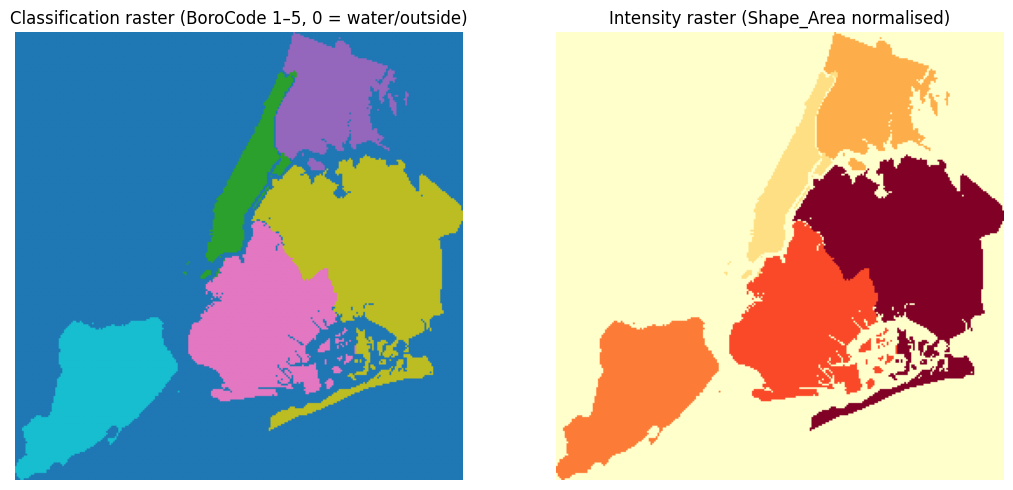

In [12]:
nrows, ncols = 256, 256
bounds = nybb.total_bounds           # (minx, miny, maxx, maxy) in EPSG:2263
transform = from_bounds(*bounds, ncols, nrows)

def _rasterize(shapes, dtype, fill=0):
    mf = MemoryFile()
    with mf.open(driver="GTiff", height=nrows, width=ncols, count=1,
                 dtype=dtype, transform=transform, crs=nybb.crs,
                 nodata=fill) as ds:
        arr = rasterize(shapes, out_shape=(nrows, ncols), transform=transform,
                        fill=fill, dtype=dtype)
        ds.write(arr[np.newaxis])
    return mf

# Classification raster (BoroCode as integer class label)
class_mf = _rasterize(
    zip(nybb.geometry, nybb.BoroCode.astype("uint8")), "uint8", fill=0
)

# Intensity raster (Shape_Area, normalised to [0, 1])
norm_area = (nybb.Shape_Area / nybb.Shape_Area.max()).values
intensity_mf = _rasterize(
    zip(nybb.geometry, norm_area.astype("float32")), "float32", fill=0.0
)

# Preview
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
with class_mf.open() as ds:
    arr_c = ds.read(1)
with intensity_mf.open() as ds:
    arr_i = ds.read(1)

axes[0].imshow(arr_c, cmap="tab10", vmin=0, vmax=5, origin="upper")
axes[0].set_title("Classification raster (BoroCode 1–5, 0 = water/outside)")
axes[1].imshow(arr_i, cmap="YlOrRd", origin="upper")
axes[1].set_title("Intensity raster (Shape_Area normalised)")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [13]:
BORO_CODE = dict(zip(nybb.BoroCode, nybb.BoroName))

with class_mf.open() as ds:
    class_arr = ds.read(1)
    pts_const_r = ConstantClassSampler(n_per_class=60, random_state=0).sample(ds, class_arr)
    pts_strat_r = StratifiedClassSampler(n_samples=300, random_state=0).sample(ds, class_arr)
    pts_multi_r = MultinomialSampler(n_samples=300, random_state=0).sample(
        ds, labels=class_arr, weights=class_arr>0,
    )

print("ConstantClassSampler — raster:")
print(pts_const_r.groupby("class_label").size().rename("n").to_string())
print("StratifiedClassSampler — raster (∝ pixel count per BoroCode):")
print(pts_strat_r.groupby("class_label").size().rename("n").to_string())
print("MultinomialSampler — raster (according to pixel count per BoroCode):")
print(pts_multi_r.groupby("class_label").size().rename("n").to_string())

ConstantClassSampler — raster:
class_label
1    60
2    60
3    60
4    60
5    60
StratifiedClassSampler — raster (∝ pixel count per BoroCode):
class_label
1     22
2     49
3     68
4    109
5     52
MultinomialSampler — raster (according to pixel count per BoroCode):
class_label
1     23
2     38
3     57
4    119
5     63


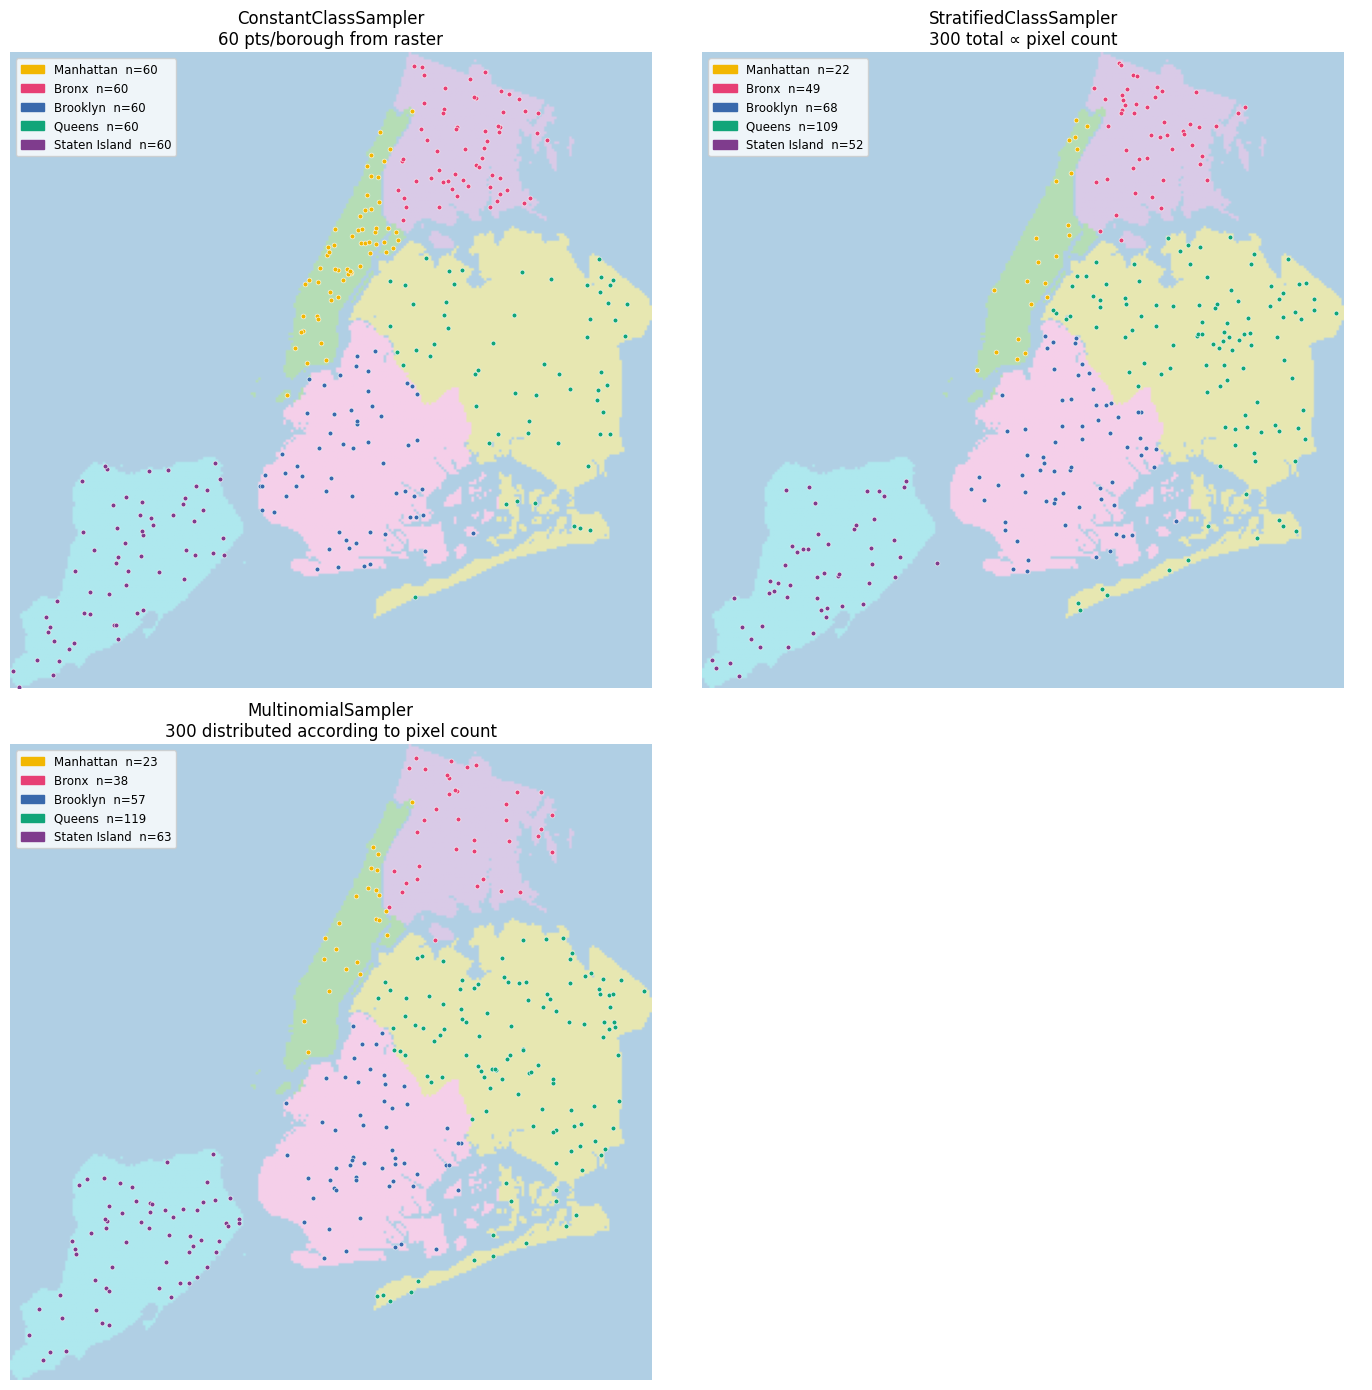

In [14]:
CODE_COLORS = {code: BORO_COLORS[name] for code, name in BORO_CODE.items()}

fig, axes = plt.subplots(2, 2, figsize=(14,14))
for ax, pts, title in [
    (axes.flat[0], pts_const_r,
     "ConstantClassSampler\n60 pts/borough from raster"),
    (axes.flat[1], pts_strat_r,
     "StratifiedClassSampler\n300 total ∝ pixel count"),
    (axes.flat[2], pts_multi_r,
     "MultinomialSampler\n300 distributed according to pixel count"),
]:
    ax.imshow(arr_c, cmap="tab10", vmin=0, vmax=5,
              origin="upper", extent=[*bounds[[0,2,1,3]]], alpha=0.35)
    for code in sorted(CODE_COLORS):
        sub = pts[pts["class_label"] == code]
        if len(sub):
            ax.scatter(sub.geometry.x, sub.geometry.y, s=12,
                       color=CODE_COLORS[code], zorder=3,
                       edgecolors="white", linewidths=0.4)
    counts = pts.groupby("class_label").size()
    patches = [mpatches.Patch(color=CODE_COLORS[k],
                              label=f"{BORO_CODE[k]}  n={counts.get(k, 0)}")
               for k in sorted(CODE_COLORS)]
    ax.legend(handles=patches, fontsize=8.5)
    ax.set_title(title, fontsize=12)
    ax.set_aspect("equal"); ax.axis("off")
axes.flat[-1].set_axis_off()
plt.tight_layout()
plt.show()